<div style="background-color:white; text-align:center; font-family:Arial, Helvetica, sans-serif; padding:50px;">
  <!-- Tytuł -->
  <div style="color:#993520; font-size:60px; font-weight:bold; margin-bottom:20px;">
    TOPIC MODELLING
  </div>

  <!-- Podtytuł -->
  <div style="color:#993520; font-size:35px; margin-bottom:40px;">
    BERTopic algorithm
  </div>

  <!-- Autor -->
  <div style="color:black; font-size:30px; margin-bottom:10px;">
    Maciej Świtała, PhD
  </div>

  <!-- Data / semestr -->
  <div style="color:black; font-size:30px; margin-bottom:50px;">
    Autumn 2025
  </div>

  <!-- Logo -->
  <div>
    <img src="img/wne-logo-new-en.jpg" alt="WNE Logo" style="max-width:400px; height:auto;">
  </div>
</div>


### 1. Intro

In [1]:
# usually umap and hdbscan require instalation of visual cpp build tools from: https://visualstudio.microsoft.com/visual-cpp-build-tools/; it takes around 15 min. and requires around 7 GB
# !pip install pandas numpy matplotlib seaborn nltk scikit-learn umap hdbscan bertopic sentence_transformers

In [1]:
import pandas as pd  # for working with data in DataFrames
import numpy as np  # numerical operations and arrays

import matplotlib.pyplot as plt  # data visualization
import seaborn as sns  # enhanced visualisation

import pickle  # data loading
import re  # text preprocessing and cleaning (regular expressions)
import math  # mathematical functions
import time
import statistics  # e.g., calculating quantiles

from itertools import combinations  # generates all possible unique combinations of length; we will need it for generating all unique pairs of keywords
from collections import Counter  # counting occurrences of elements

from nltk.tokenize import RegexpTokenizer  # tokenizes text using regular expressions

from sklearn.feature_extraction.text import CountVectorizer  # converts text into a matrix of token counts
from sklearn.feature_extraction.text import TfidfVectorizer  # converts text into a matrix of token TF-IDFs

from sentence_transformers import SentenceTransformer  # loads transformer of our choice
# from umap import UMAP  # dimensionality reduction technique for visualization or preprocessing
from hdbscan import HDBSCAN  # density-based clustering algorithm for finding clusters of varying shapes/sizes
from bertopic import BERTopic  # topic modeling library based on transformers and clustering
from bertopic.vectorizers import ClassTfidfTransformer  # improves topic representations using class-based TF-IDF
from bertopic.representation import KeyBERTInspired  # representation model for fine-tuning topic descriptions

In [3]:
# let us load an example dataset
with open("data/cnn-climate-news.txt", "rb") as fp:
    data = pickle.load(fp)

In [4]:
# initial inspection of the first five news
data[0:5]

['CNN\n — \nA mysterious type of magma found within extinct volcanoes scattered around the world could contain an abundant supply of rare earth elements, crucial ingredients for electric vehicles, wind turbines and other clean technologies, according to a report published Tuesday.\nRare earth elements, such as lanthanum, neodymium and terbium, are critical for helping the world break its long, destructive relationship with planet-heating fossil fuels.\nThese materials — so-called rare earths — are not actually that rare but can be challenging to extract as they are often found in low concentrations. As demand for them ramps up, many countries are scrambling to find new sources to break their dependence on China, which currently dominates the supply chain.\nThe new study “potentially opens a new avenue for rare earth extraction,” said Michael Anenburg, a research fellow at the Australian National University and a study author.\nThe research was inspired by last year’s discovery of an en

In [5]:
# the data are stored in a list
type(data)

list

In [6]:
# 187 texts - good for us, the computation shall be quick
len(data)

187

In [7]:
# cnn data is a list of texts
texts_lengths = [len(text) for text in data]  # get the length of each text

# basic descriptive statistics of the texts length
print("Min. =", np.round(min(texts_lengths),2))                     # minimum length
print("Max. =", np.round(max(texts_lengths),2))                     # maximum length
print("Mean =", np.round(statistics.mean(texts_lengths),2))         # average length
print("Median =", np.round(statistics.median(texts_lengths),2))     # median length
print("Std. dev. =", np.round(statistics.stdev(texts_lengths),2))   # standard deviation

# most importantly: there are no empty documents; the shortest are 3/4 of the A4 page

Min. = 1448
Max. = 17122
Mean = 5714.9
Median = 5186
Std. dev. = 2807.44


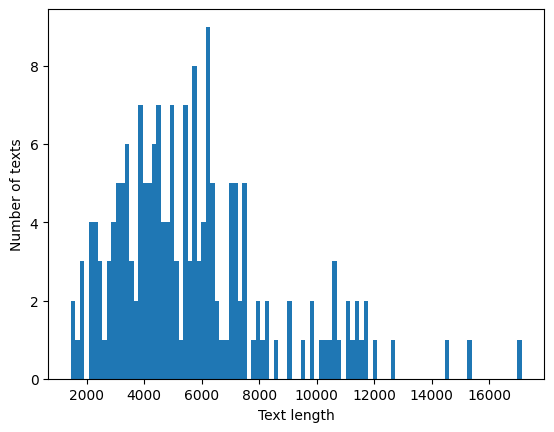

In [8]:
# plot a histogram of text lengths
plt.hist(texts_lengths, bins=100)
plt.xlabel('Text length')
plt.ylabel('Number of texts')
plt.show()

In [9]:
# we should always check for duplicates; here there is no such an issue
has_duplicates = len(data) != len(set(data))
print("Contains duplicates?", has_duplicates)

Contains duplicates? False


### 2. Data preprocessing

In [10]:
# BERT does not require any data preprocessing!; still, it is quite sensitive to capital letters
# as a result, we need to convert all letters to lower case; this is also recommended by the BERTopic funder - Martin Grootendorst
texts = [text.lower() for text in data]

In [11]:
# still, we should explore the data more to specify the possible hyperparameters of the algorithm later on
# let us load the preprocessed data
texts_cleaned_loaded = []
with open("data/cnn-climate-news_cleaned.txt", "r", encoding="utf-8") as f:
    for line in f:
        # split the line back into tokens (words), since they were joined with spaces before
        tokens = line.strip().split()
        texts_cleaned_loaded.append(tokens)

In [12]:
# this function generates n-grams for a list of tokens over a specified range of n values
def generate_ngrams(tokens, ngram_range=(1,3)):

    all_ngrams = []  # this list will store all generated n-grams

    # loop over each n in the range (e.g., 1, 2, 3)
    for n in range(ngram_range[0], ngram_range[1]+1):
        # create sliding windows of length n
        ngrams = zip(*[tokens[i:] for i in range(n)])  # e.g., for bigrams: [tokens[0:], tokens[1:]]
        
        # join tokens with underscores to form n-gram strings
        all_ngrams.extend(['_'.join(gram) for gram in ngrams])
    
    return all_ngrams  # return the complete list of n-grams

# apply n-gram generation to all cleaned texts
# texts_cleaned is a list of documents, each a list of tokens
texts_with_ngrams = [generate_ngrams(doc, ngram_range=(1,3)) for doc in texts_cleaned_loaded]

# after this step:
# - texts_with_ngrams[i] contains all unigrams, bigrams, and trigrams for document i
# - each n-gram is a single string (e.g., "new_york", "war_in_ukraine")

In [13]:
# this function computes TF, DF, IDF, TF-IDF for all the tokens under consideration

def compute_tfidf(texts):

    N = len(texts)  # number of documents
    
    # 1. Compute TF for each document
    tf_docs = []
    for doc in texts:
        counts = Counter(doc)
        total_words = len(doc)
        tf_doc = {word: count / total_words for word, count in counts.items()}
        tf_docs.append(tf_doc)
    
    # 2. Compute DF for each token (fraction of docs containing the token)
    df_dict = {}
    for doc in texts:
        for token in set(doc):
            df_dict[token] = df_dict.get(token, 0) + 1
    df_dict = {token: count / N for token, count in df_dict.items()}
    
    # 3. Compute IDF
    idf_dict = {token: math.log(1 / df) for token, df in df_dict.items()}
    
    # 4. Compute TF-IDF for each document
    tfidf_docs = []
    for tf_doc in tf_docs:
        tfidf_doc = {token: tf_val * idf_dict[token] for token, tf_val in tf_doc.items()}
        tfidf_docs.append(tfidf_doc)
    
    return tf_docs, df_dict, idf_dict, tfidf_docs

tf_docs, df_dict, idf_dict, tfidf_docs = compute_tfidf(texts_with_ngrams)

# usually we are interested in DF, primarily due to its intuitive interpretation
# initial analysis of DF is the first step towards filtering out the too frequent and too rare tokens

# let us sort DF dictionary in descending order and take top 100
top100_df = dict(sorted(df_dict.items(), key=lambda item: item[1], reverse=True)[:100])

# here we present top 25 tokens according to DF statistic
for token, df in top100_df.items():
    print(f"{token}: {df:.3f}")

cnn: 0.979
said: 0.952
climate: 0.914
year: 0.882
also: 0.813
told: 0.749
world: 0.738
new: 0.733
one: 0.733
change: 0.733
according: 0.717
related: 0.706
time: 0.701
could: 0.684
related_article: 0.679
article: 0.679
told_cnn: 0.663
around: 0.642
people: 0.636
like: 0.631
including: 0.626
climate_change: 0.604
last: 0.599
even: 0.599
part: 0.599
country: 0.588
scientist: 0.583
global: 0.583
fuel: 0.556
water: 0.551
state: 0.540
many: 0.540
much: 0.540
impact: 0.540
temperature: 0.529
say: 0.524
u: 0.524
way: 0.524
level: 0.513
would: 0.508
university: 0.492
found: 0.492
added: 0.492
still: 0.492
make: 0.487
heat: 0.487
may: 0.471
report: 0.465
research: 0.465
two: 0.465
million: 0.460
need: 0.460
decade: 0.460
day: 0.460
high: 0.449
across: 0.449
first: 0.449
image: 0.444
energy: 0.433
natural: 0.433
since: 0.433
record: 0.433
get: 0.428
national: 0.428
come: 0.428
take: 0.422
fossil: 0.422
pollution: 0.422
made: 0.422
fossil_fuel: 0.412
crisis: 0.412
used: 0.412
show: 0.406
–: 0.406


In [14]:
# get all DF values
df_values = list(df_dict.values())

# basic statistics
print("Min. =", np.round(min(df_values), 3))
print("Max. =", np.round(max(df_values), 3))
print("Mean =", np.round(statistics.mean(df_values), 3))
print("Median =", np.round(statistics.median(df_values), 3))
print("Std. dev. =", np.round(statistics.stdev(df_values), 3))

Min. = 0.005
Max. = 0.979
Mean = 0.007
Median = 0.005
Std. dev. = 0.017


In [15]:
# different quantiles visualise the common problem - usually a vast majority of tokens is observed only once
for i in range(10,100,10):
    print(i,'%-quantile: ',np.round(np.quantile(df_values, i/100),3),sep='')

10%-quantile: 0.005
20%-quantile: 0.005
30%-quantile: 0.005
40%-quantile: 0.005
50%-quantile: 0.005
60%-quantile: 0.005
70%-quantile: 0.005
80%-quantile: 0.005
90%-quantile: 0.005


In [16]:
# different quantiles visualise the common problem - usually a vast majority of tokens is observed only once
for i in range(90,100,1):
    print(i,'%-quantile: ',np.round(np.quantile(df_values, i/100),3),sep='')

90%-quantile: 0.005
91%-quantile: 0.005
92%-quantile: 0.011
93%-quantile: 0.011
94%-quantile: 0.011
95%-quantile: 0.011
96%-quantile: 0.011
97%-quantile: 0.016
98%-quantile: 0.021
99%-quantile: 0.043


In [17]:
# different quantiles visualise the common problem - usually a vast majority of tokens is observed only once
for i in range(990,1000,1):
    print(i/10,'%-quantile: ',np.round(np.quantile(df_values, i/1000),3),sep='')

99.0%-quantile: 0.043
99.1%-quantile: 0.048
99.2%-quantile: 0.053
99.3%-quantile: 0.059
99.4%-quantile: 0.07
99.5%-quantile: 0.086
99.6%-quantile: 0.102
99.7%-quantile: 0.128
99.8%-quantile: 0.171
99.9%-quantile: 0.246


### 4. BERTopic algorithm

#### 4.1. BERTopic with manually specified hyperparameters

In [18]:
# Step 1 - Extract embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Step 2 - Reduce dimensionality
umap_model = UMAP(
        n_neighbors = 15,        # number of neighbors used to build local manifold structure
        n_components = 5,        # number of dimensions for the reduced embeddings
        metric = 'cosine',       # distance metric used for measuring similarity
        min_dist = 0.0,          # minimum distance between points in the low-dimensional space
        random_state = 42        # random seed for reproducibility
        )

# Step 3 - Cluster reduced embeddings
hdbscan_model = HDBSCAN(
        min_cluster_size = 2,             # minimum size of clusters; smaller groups are labeled as noise
        metric = 'euclidean',             # distance metric for clustering
        cluster_selection_method = 'eom', # method for selecting clusters ("eom" = excess of mass)
        prediction_data = True            # store extra data for prediction of new points
        )

# Step 4 - Tokenize topics
tokenizer = RegexpTokenizer(r'\w+')

tf_vectorizer = CountVectorizer(
        ngram_range = (1, 3),           # specify n-grams
        max_df = 1.0,                   # filter by maximum document frequency
        min_df = 0.0,                   # filter by minimum document frequency
        tokenizer = tokenizer.tokenize, # apply custom tokenizer
        stop_words = []                 # provide stopword list if needed
        )

# Step 5 - Create topic representation
ctfidf_model = ClassTfidfTransformer()

# Step 6 - (Optional) Fine-tune topic representations with a `bertopic.representation` model
representation_model = KeyBERTInspired()

# Step 7 - Build the BERTopic pipeline
topic_model = BERTopic(
        embedding_model = embedding_model,             # Step 1 - Extract embeddings; alternative: specify language option
        umap_model = umap_model,                       # Step 2 - Reduce dimensionality
        hdbscan_model = hdbscan_model,                 # Step 3 - Cluster reduced embeddings
        vectorizer_model = tf_vectorizer,              # Step 4 - Tokenize topics
        ctfidf_model = ctfidf_model,                   # Step 5 - Create topic representation
        representation_model = representation_model,   # Step 6 - Fine-tune topic representations
        top_n_words = 10,
        calculate_probabilities = True
        )

# Step 8 - Fit the model and transform input texts
topics, probabilities = topic_model.fit_transform(texts)

In [19]:
# with the manually specified hyperparameters we obtained only 2 topics
# as BERTopic utilises Sentence-BERT, we shoudl rather base our interpretation on the sentences, here let us consider topic-representative documents 
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,114,0_warming_climate change_told cnn_climate,"[warming, climate change, told cnn, climate, s...",[cnn\n — \ntensions are rising in a border dis...
1,1,73,1_solar_hydrogen_climate_coal,"[solar, hydrogen, climate, coal, fuel, energy,...",[london\ncnn\n — \nas right-wing rioters attac...


#### 4.2. Hyperparameters optimisation

In [22]:
# count the number of documents containing a given word
def doc_freq(word):
    return sum(1 for doc in docs_as_sets if word in doc)

# count the number of documents containing both w1 and w2
def co_doc_freq(w1, w2):
    return sum(1 for doc in docs_as_sets if w1 in doc and w2 in doc)

# compute UMass coherence for a list of words (e.g., top words in a cluster/topic),normalized by the total number of word pairs
def umass_coherence(words, eps=1e-12):
    scores_sum = 0.0
    n_pairs = 0
    for w1, w2 in combinations(words, 2):  # iterate over all unique word pairs
        D_w1w2 = co_doc_freq(w1, w2)       # number of documents containing both words
        D_w2 = doc_freq(w2)                 # number of documents containing second word
        if D_w2 == 0:                       # skip to avoid division by zero
            continue
        scores_sum += np.log((D_w1w2 + eps) / D_w2)  # log-ratio with smoothing
        n_pairs += 1
    # normalize by total number of word pairs: 2 / (N*(N-1))
    return scores_sum * 2 / (len(words) * (len(words) - 1)) if n_pairs > 0 else 0.0

# compute UCI coherence (average PMI) for a list of words, normalized by all word pairs
def uci_coherence(words, eps=1e-12):
    scores_sum = 0.0
    n_pairs = 0
    for w1, w2 in combinations(words, 2):
        p_w1 = doc_freq(w1) / N           # probability of first word
        p_w2 = doc_freq(w2) / N           # probability of second word
        p_w1w2 = co_doc_freq(w1, w2) / N  # joint probability
        if p_w1 == 0 or p_w2 == 0:
            continue
        scores_sum += np.log((p_w1w2 + eps) / (p_w1 * p_w2))  # PMI
        n_pairs += 1
    return scores_sum * 2 / (len(words) * (len(words) - 1)) if n_pairs > 0 else 0.0

# compute UCI-style coherence using Normalized PMI (NPMI) for a list of words, normalized by all possible word pairs.
def uci_npmi_coherence(words, eps=1e-12):
    scores_sum = 0.0
    n_pairs = 0
    for w1, w2 in combinations(words, 2):
        p_w1 = doc_freq(w1) / N
        p_w2 = doc_freq(w2) / N
        p_w1w2 = co_doc_freq(w1, w2) / N
        if p_w1w2 == 0:
            continue
        pmi = np.log((p_w1w2 + eps) / (p_w1 * p_w2))  # compute PMI
        npmi = pmi / (-np.log(p_w1w2 + eps))          # normalize PMI
        scores_sum += npmi
        n_pairs += 1
    return scores_sum * 2 / (len(words) * (len(words) - 1)) if n_pairs > 0 else 0.0

In [ ]:
start = time.time()

results = []

# components initialised
tokenizer = RegexpTokenizer(r'\w+') # tokenizer
embedding_model = SentenceTransformer("all-MiniLM-L6-v2") # embedding model
ctfidf_model = ClassTfidfTransformer()  # topic representation transformer
representation_model = KeyBERTInspired()  # topic representation model

# prepare documents as sets of words (needed for doc_freq and co_doc_freq)
docs_as_sets = [set(tokenizer.tokenize(doc.lower())) for doc in texts] # texts as set
N = len(docs_as_sets) # number of texts

for ngram_range in [1, 3]:
    for max_df in [1.0, np.quantile(df_values, 0.99)]:
        for min_df in [1, 2]:
            for vectoriser in ['tf', 'tfidf']:
                if vectoriser=='tf':

                    vectorizer = CountVectorizer(encoding = 'utf-8', # if bytes to analyze, this encoding will be used
                                                    decode_error = 'strict', # if we want to get an error in case of encoding error
                                                    strip_accents = None, # if we want to do something we accents
                                                    
                                                    lowercase = True, # all letters to lower case
                                                    ngram_range = (1, ngram_range), # what kind of ngrams do we want 
                                                    
                                                    max_df = max_df, # filtering with document frequency, float means percentage, i.e., 1.0 denotes 100% (maximum DF value), integer means df value specifically
                                                    min_df = min_df, # filtering with document frequency
                                                    max_features = None, # if we want to use only the tokens with top document frequency
                                                    
                                                    tokenizer = tokenizer.tokenize # tokenizer
                    )

                    fit = vectorizer.fit_transform(texts) # using raw data for now
                    feature_names = vectorizer.get_feature_names_out() # feature names

                if vectoriser=='tfidf':
                    vectorizer = TfidfVectorizer(encoding = 'utf-8', # if bytes to analyze, this encoding will be used
                                                    decode_error = 'strict', # if we want to get an error in case of encoding error
                                                    strip_accents = None, # if we want to do something we accents
                                                    
                                                    lowercase = True, # all letters to lower case
                                                    ngram_range = (1, ngram_range), # what kind of ngrams do we want 
                                                    
                                                    max_df = max_df, # filtering with document frequency, float means percentage, i.e., 1.0 denotes 100% (maximum DF value), integer means df value specifically
                                                    min_df = min_df, # filtering with document frequency
                                                    max_features = None, # if we want to use only the tokens with top document frequency
                                                    
                                                    tokenizer = tokenizer.tokenize # tokenizer
                    )

                    fit = vectorizer.fit_transform(texts) # using raw data for now
                    feature_names = vectorizer.get_feature_names_out() # feature names

                for n_neighbors in [15]:
                      for n_components in [5]:
                            for metric_umap in ['cosine']:
                                  for min_dist in [0.0, 0.05, 0.1]:

                                    # Reduce dimensionality
                                    umap_model = UMAP(
                                            n_neighbors = n_neighbors,      # number of neighbors used to build local manifold structure
                                            n_components = n_components,    # number of dimensions for the reduced embeddings
                                            metric = metric_umap,           # distance metric used for measuring similarity
                                            min_dist = min_dist,            # minimum distance between points in the low-dimensional space
                                            random_state = 42               # random seed for reproducibility
                                            )

                                    for min_cluster_size in [2, 5, 10]:
                                          for metric_hdbscan in ['euclidean']:
                                                for cluster_selection_method in ['eom']:

                                                    # Cluster reduced embeddings
                                                    hdbscan_model = HDBSCAN(
                                                            min_cluster_size = min_cluster_size,                 # minimum size of clusters; smaller groups are labeled as noise
                                                            metric = metric_hdbscan,                             # distance metric for clustering
                                                            cluster_selection_method = cluster_selection_method, # method for selecting clusters ("eom" = excess of mass)
                                                            prediction_data = True                               # store extra data for prediction of new points
                                                            )
                                                    
                                                    # Possible automatic merging of the topics
                                                    for nr_topics in [True, False]:

                                                        if nr_topics:

                                                            # Build the BERTopic pipeline
                                                            topic_model = BERTopic(
                                                                    embedding_model = embedding_model,             # Step 1 - Extract embeddings; alternative: specify language option
                                                                    umap_model = umap_model,                       # Step 2 - Reduce dimensionality
                                                                    hdbscan_model = hdbscan_model,                 # Step 3 - Cluster reduced embeddings
                                                                    vectorizer_model = vectorizer,                 # Step 4 - Tokenize topics
                                                                    ctfidf_model = ctfidf_model,                   # Step 5 - Create topic representation
                                                                    representation_model = representation_model,   # Step 6 - Fine-tune topic representations
                                                                    top_n_words = 10,
                                                                    calculate_probabilities = True,
                                                                    nr_topics = "auto"
                                                                    )
                                                            
                                                        else:

                                                            # Build the BERTopic pipeline
                                                            topic_model = BERTopic(
                                                                    embedding_model = embedding_model,             # Step 1 - Extract embeddings; alternative: specify language option
                                                                    umap_model = umap_model,                       # Step 2 - Reduce dimensionality
                                                                    hdbscan_model = hdbscan_model,                 # Step 3 - Cluster reduced embeddings
                                                                    vectorizer_model = vectorizer,                 # Step 4 - Tokenize topics
                                                                    ctfidf_model = ctfidf_model,                   # Step 5 - Create topic representation
                                                                    representation_model = representation_model,   # Step 6 - Fine-tune topic representations
                                                                    top_n_words = 10,
                                                                    calculate_probabilities = True
                                                                    )

                                                        try:
                                                            # Fit the model and transform input texts
                                                            topics, probabilities = topic_model.fit_transform(texts)

                                                            # Extract top words for each topic
                                                            topic_info = topic_model.get_topic_info()
                                                            topics_list = topic_info.Topic[topic_info.Topic != -1]  # skip the "noise" topic (-1)

                                                            n_topics = len(topics_list)

                                                            topic_words = {}
                                                            for t in topics_list:
                                                                words_and_scores = topic_model.get_topic(t)
                                                                words = [w for w, _ in words_and_scores]
                                                                topic_words[t] = words

                                                                # compute coherence for each topic
                                                                coherence_results = []

                                                            for t, words in topic_words.items():
                                                                umass = umass_coherence(words)
                                                                uci = uci_coherence(words)
                                                                npmi = uci_npmi_coherence(words)

                                                            results.append([
                                                                ngram_range, max_df, min_df, vectoriser, 
                                                                n_neighbors, n_components, metric_umap, min_dist,
                                                                min_cluster_size, metric_hdbscan, cluster_selection_method,
                                                                nr_topics, umass, uci, npmi, n_topics
                                                                ])

                                                            with open("outputs/bertopic_optimisation_results.pkl", "wb") as f:
                                                                pickle.dump(results, f)

                                                            print(
                                                                ngram_range, max_df, min_df, vectoriser, 
                                                                n_neighbors, n_components, metric_umap, min_dist, 
                                                                min_cluster_size, metric_hdbscan, cluster_selection_method, 
                                                                nr_topics, umass, uci, npmi, n_topics
                                                            )

                                                        except:
                                                            continue

end = time.time()
elapsed_sec = end - start
elapsed_min = elapsed_sec / 60

print(f"Elapsed time: {elapsed_min:.2f} minutes") # it takes ~75 min.

1 1.0 1 tf 15 5 cosine 0.0 2 euclidean eom True -0.8787237559630564 0.5735402233015356 0.24171461546051284 2
1 1.0 1 tf 15 5 cosine 0.0 2 euclidean eom False -0.9728755725550818 0.5421761297467302 0.20242789863374616 2
1 1.0 1 tf 15 5 cosine 0.0 5 euclidean eom True -0.8787237559630564 0.5735402233015356 0.24171461546051284 2
1 1.0 1 tf 15 5 cosine 0.0 5 euclidean eom False -0.9728755725550818 0.5421761297467302 0.20242789863374616 2
1 1.0 1 tf 15 5 cosine 0.0 10 euclidean eom True -0.976701229701898 0.4755627495616748 0.20778259760887607 2
1 1.0 1 tf 15 5 cosine 0.0 10 euclidean eom False -0.9029981217396812 0.5378667267017657 0.200395697820973 2
1 1.0 1 tf 15 5 cosine 0.05 2 euclidean eom True -4.734806610425755 -1.0143860785689052 0.3590352746433817 13
1 1.0 1 tf 15 5 cosine 0.05 2 euclidean eom False -1.4821760266899335 0.5409062774311675 0.13128778530572077 13
1 1.0 1 tf 15 5 cosine 0.05 5 euclidean eom True -0.976701229701898 0.4755627495616748 0.20778259760887607 2
1 1.0 1 tf 15

In [24]:
with open("outputs/bertopic_optimisation_results.pkl", "rb") as f:
    results = pickle.load(f)

results_df = pd.DataFrame(results)
results_df.columns = ['ngram_range', 'max_df', 'min_df', 'vectoriser', 'n_neighbors', 'n_components', 'metric_umap', 'min_dist', 'min_cluster_size', 'metric_hdbscan', 'cluster_selection_method', 'nr_topics', 'umass', 'uci', 'npmi', 'n_topics']

In [25]:
results_df.sort_values('umass', ascending=False).head(5)

,ngram_range,max_df,min_df,vectoriser,n_neighbors,n_components,metric_umap,min_dist,min_cluster_size,metric_hdbscan,cluster_selection_method,nr_topics,umass,uci,npmi,n_topics
129,3,1.0,2,tfidf,15,5,cosine,0.0,5,euclidean,eom,False,-0.575735,0.403798,0.163992,2
139,3,1.0,2,tfidf,15,5,cosine,0.1,2,euclidean,eom,False,-0.575735,0.403798,0.163992,2
111,3,1.0,2,tf,15,5,cosine,0.0,5,euclidean,eom,False,-0.575735,0.403798,0.163992,2
109,3,1.0,2,tf,15,5,cosine,0.0,2,euclidean,eom,False,-0.575735,0.403798,0.163992,2
121,3,1.0,2,tf,15,5,cosine,0.1,2,euclidean,eom,False,-0.575735,0.403798,0.163992,2


In [26]:
results_df.sort_values('uci', ascending=False).head(5)

,ngram_range,max_df,min_df,vectoriser,n_neighbors,n_components,metric_umap,min_dist,min_cluster_size,metric_hdbscan,cluster_selection_method,nr_topics,umass,uci,npmi,n_topics
60,1,1.0,2,tfidf,15,5,cosine,0.05,2,euclidean,eom,True,-2.321150,0.909869,0.432516,13
42,1,1.0,2,tf,15,5,cosine,0.05,2,euclidean,eom,True,-2.321150,0.909869,0.432516,13
32,1,1.0,1,tfidf,15,5,cosine,0.10,5,euclidean,eom,True,-1.204946,0.643988,0.225877,2
34,1,1.0,1,tfidf,15,5,cosine,0.10,10,euclidean,eom,True,-1.204946,0.643988,0.225877,2
68,1,1.0,2,tfidf,15,5,cosine,0.10,5,euclidean,eom,True,-0.911849,0.601844,0.232490,2


In [27]:
results_df.sort_values('npmi', ascending=False).head(5)

,ngram_range,max_df,min_df,vectoriser,n_neighbors,n_components,metric_umap,min_dist,min_cluster_size,metric_hdbscan,cluster_selection_method,nr_topics,umass,uci,npmi,n_topics
60,1,1.0,2,tfidf,15,5,cosine,0.05,2,euclidean,eom,True,-2.321150,0.909869,0.432516,13
42,1,1.0,2,tf,15,5,cosine,0.05,2,euclidean,eom,True,-2.321150,0.909869,0.432516,13
24,1,1.0,1,tfidf,15,5,cosine,0.05,2,euclidean,eom,True,-4.963825,-1.127158,0.422919,13
6,1,1.0,1,tf,15,5,cosine,0.05,2,euclidean,eom,True,-4.734807,-1.014386,0.359035,13
128,3,1.0,2,tfidf,15,5,cosine,0.00,5,euclidean,eom,True,-0.730282,0.568471,0.272332,2


In [28]:
# select the last three columns as metrics
metrics = ['umass','uci','npmi']

# normalize each metric using min-max normalization
normalized = results_df[metrics].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# create a new column as the sum of the normalized metrics
results_df['sum_normalised'] = normalized.sum(axis=1)

results_df.sort_values('sum_normalised', ascending=False).head(5)

,ngram_range,max_df,min_df,vectoriser,n_neighbors,n_components,metric_umap,min_dist,min_cluster_size,metric_hdbscan,cluster_selection_method,nr_topics,umass,uci,npmi,n_topics,sum_normalised
60,1,1.0,2,tfidf,15,5,cosine,0.05,2,euclidean,eom,True,-2.321150,0.909869,0.432516,13,2.844781
42,1,1.0,2,tf,15,5,cosine,0.05,2,euclidean,eom,True,-2.321150,0.909869,0.432516,13,2.844781
110,3,1.0,2,tf,15,5,cosine,0.00,5,euclidean,eom,True,-0.730282,0.568471,0.272332,2,2.501770
108,3,1.0,2,tf,15,5,cosine,0.00,2,euclidean,eom,True,-0.730282,0.568471,0.272332,2,2.501770
128,3,1.0,2,tfidf,15,5,cosine,0.00,5,euclidean,eom,True,-0.730282,0.568471,0.272332,2,2.501770


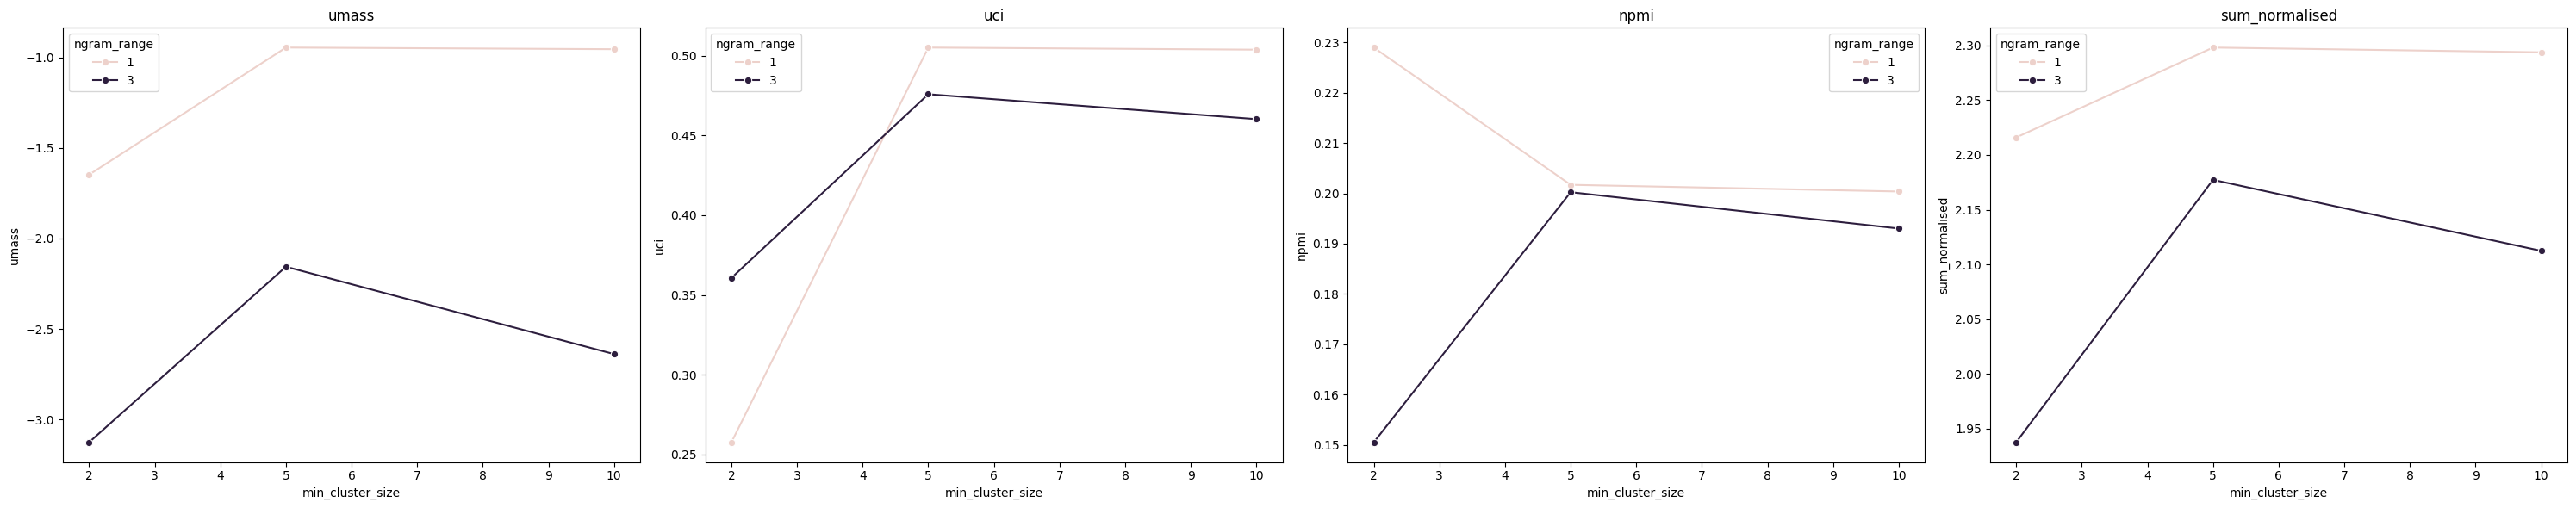

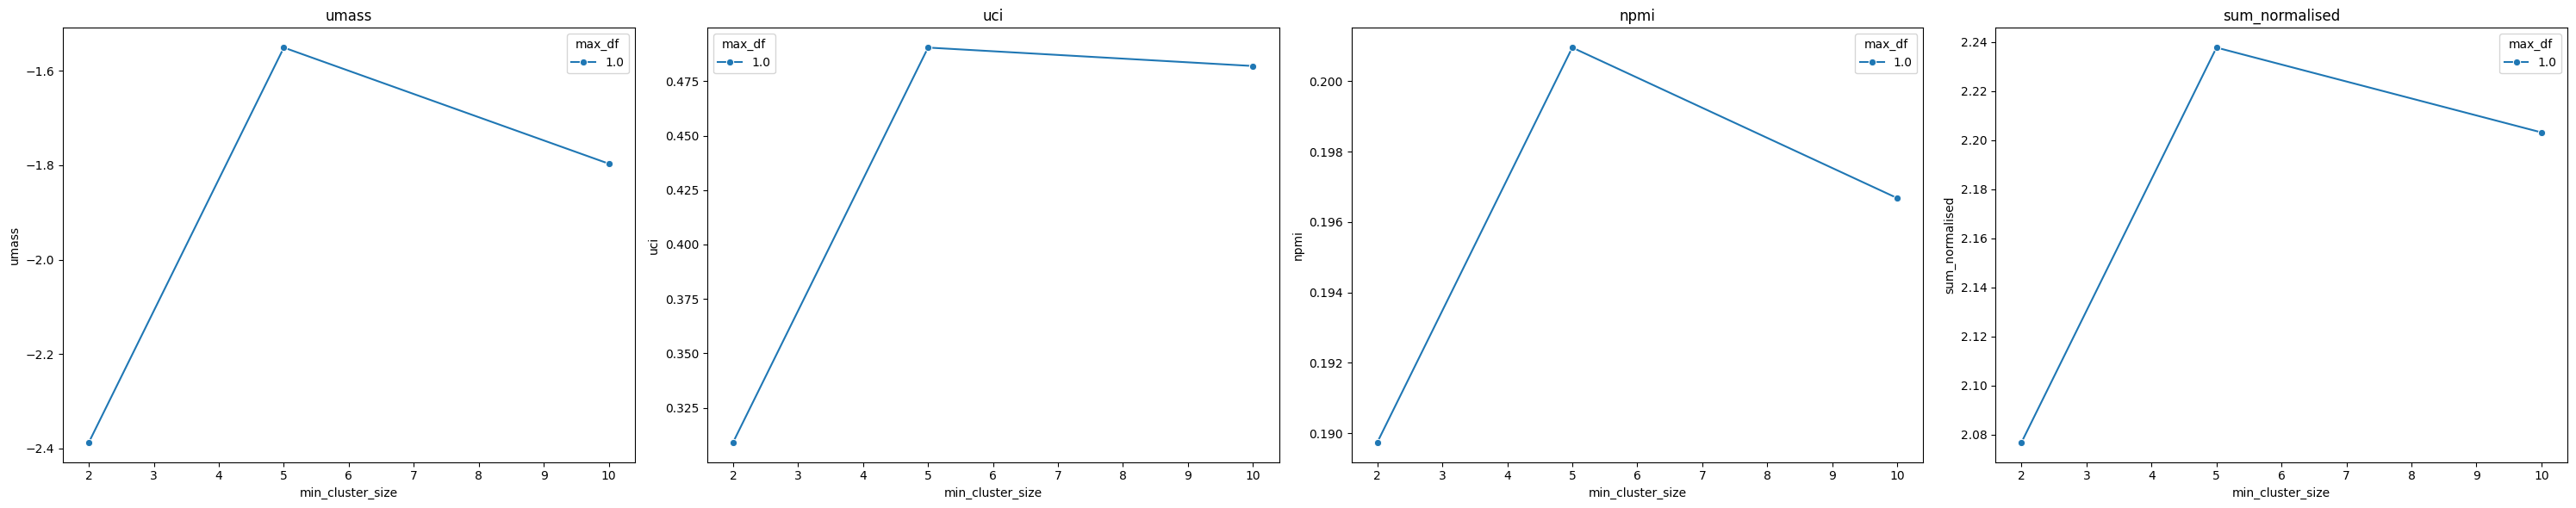

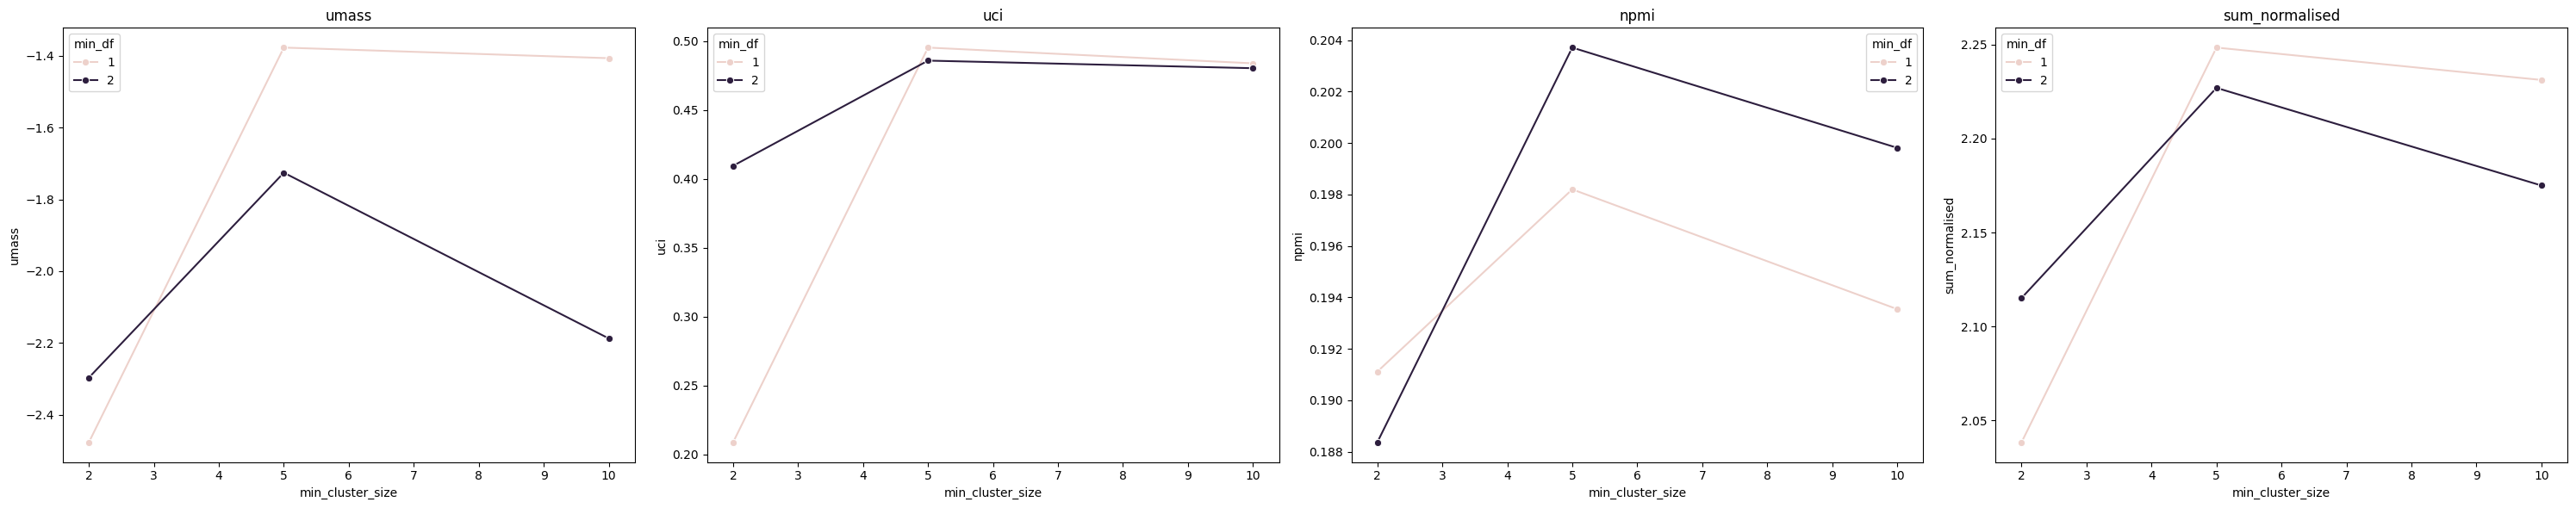

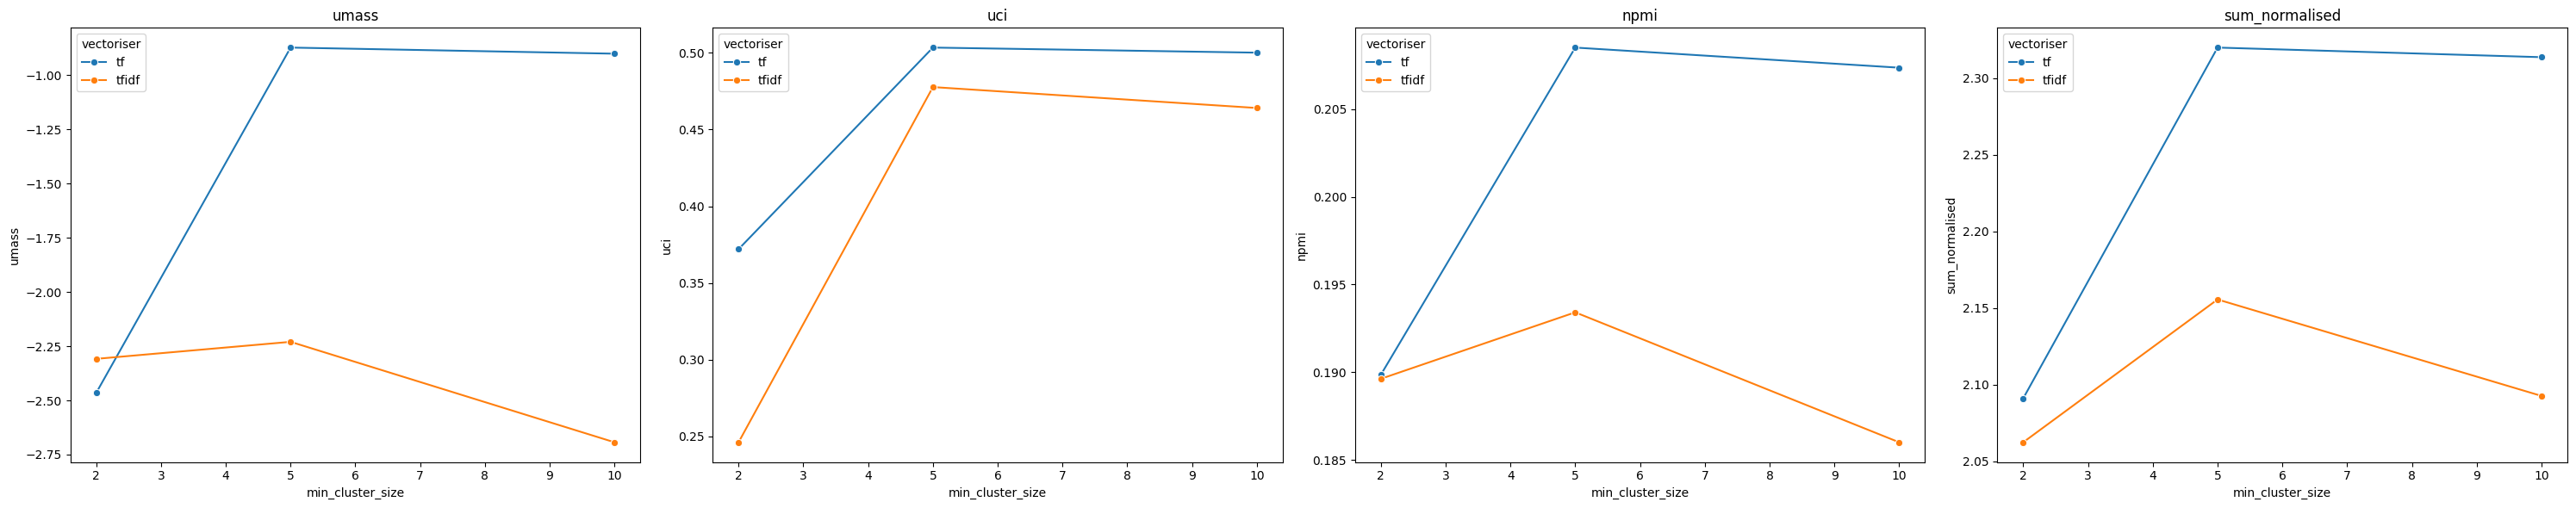

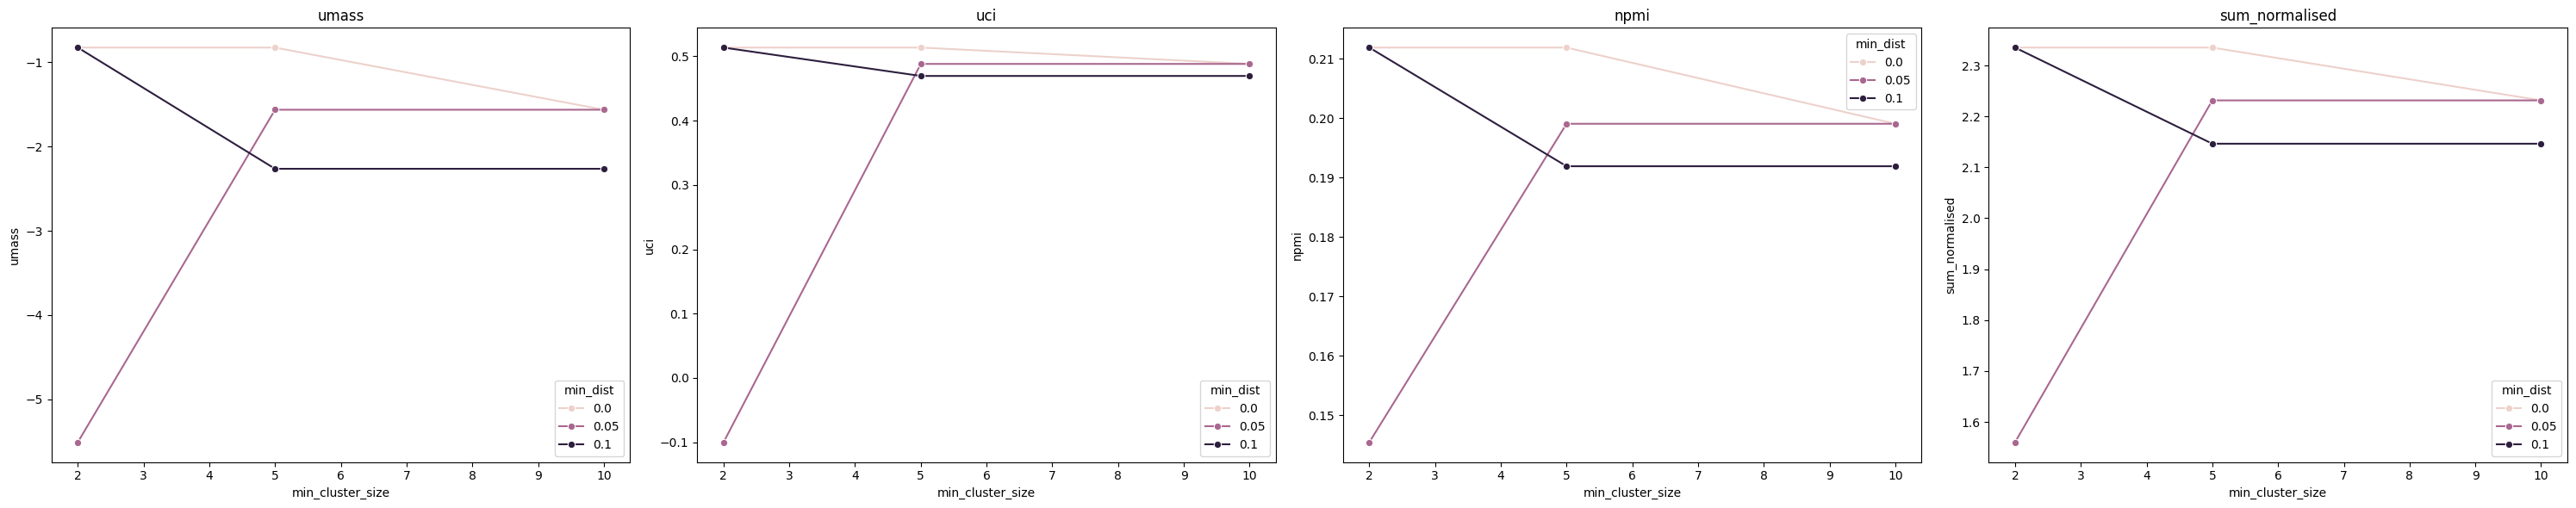

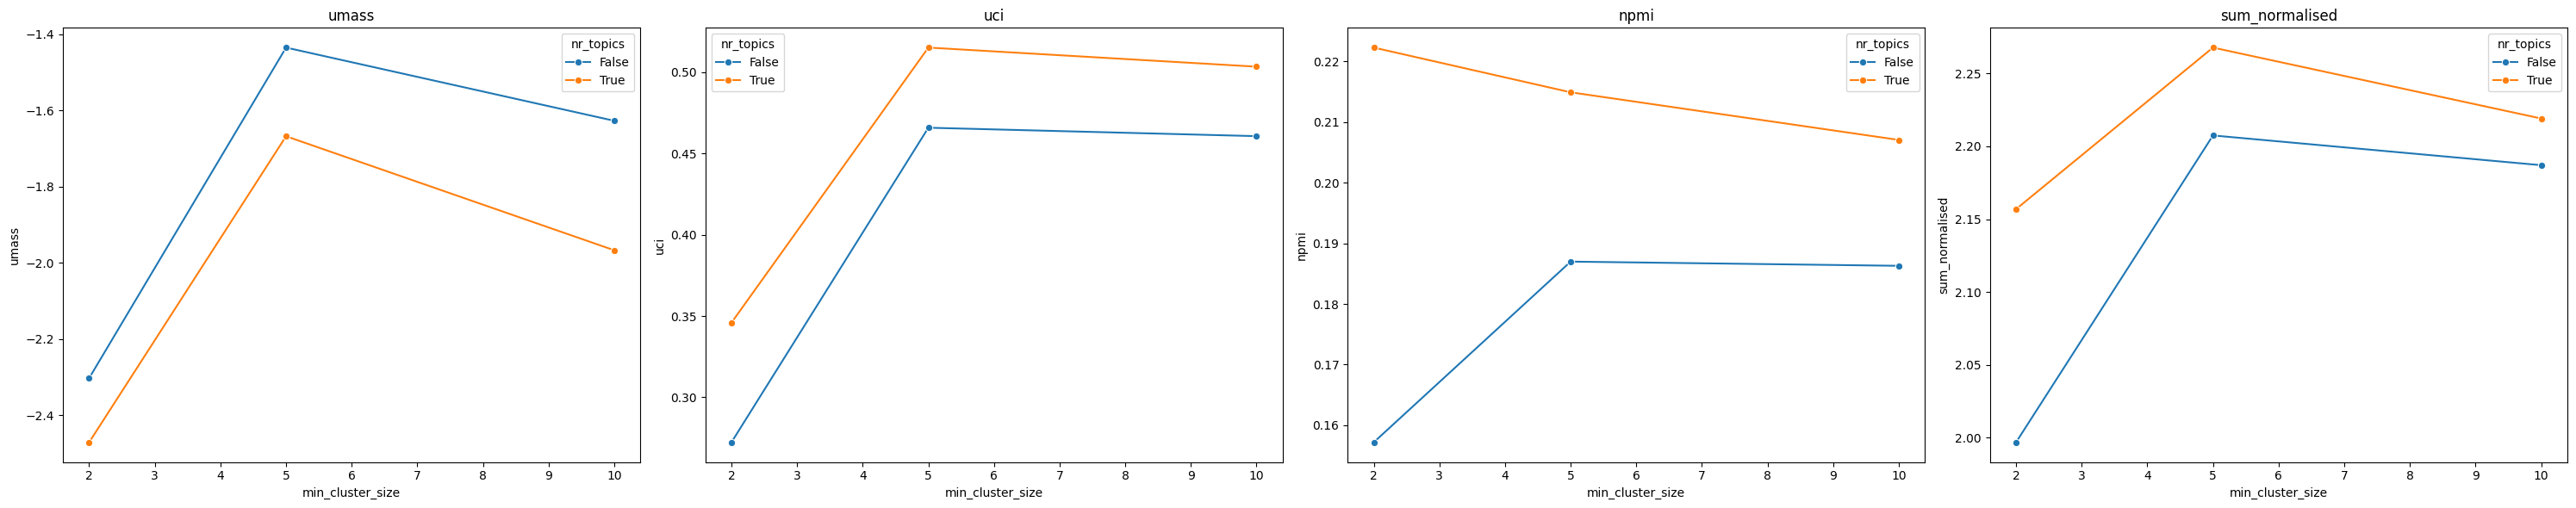

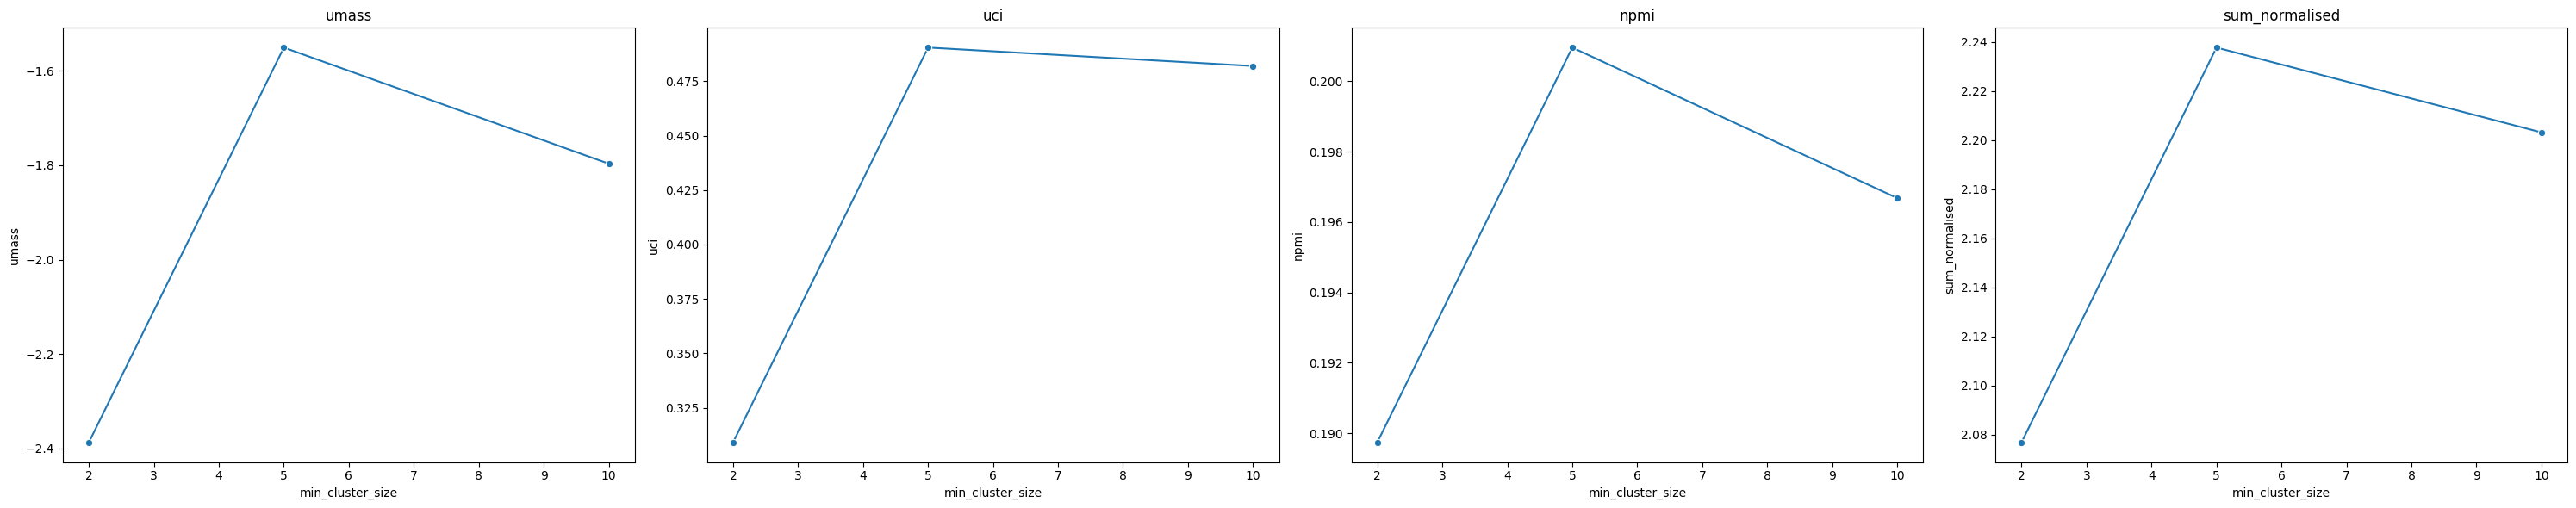

In [29]:
# let us examine the results with extra plots, showing coherence in subgroups of model parameters

# plot four line charts side by side for the last three metrics plus sum_normalized
def plot_four_line_charts(df, cols):

    # ensure cols is a list
    if isinstance(cols, str):
        cols = [cols]
    if not (1 <= len(cols) <= 2):
        raise ValueError("Provide one or two column names.")

    metrics = ['umass','uci','npmi','sum_normalised']
    fig, axes = plt.subplots(1, 4, figsize=(30, 6))

    x_col = cols[0]
    hue_col = cols[1] if len(cols) == 2 else None

    for ax, metric in zip(axes, metrics):
        if hue_col:
            sns.lineplot(data=df, x=x_col, y=metric, hue=hue_col, marker='o', ax=ax, errorbar=None)
        else:
            sns.lineplot(data=df, x=x_col, y=metric, marker='o', ax=ax, errorbar=None)

        ax.set_title(metric)
        ax.set_xlabel(x_col)
        ax.set_ylabel(metric)
        if hue_col:
            ax.legend(title=hue_col)

    plt.tight_layout()
    plt.show()

plot_four_line_charts(results_df, ['min_cluster_size', 'ngram_range'])
plot_four_line_charts(results_df, ['min_cluster_size', 'max_df'])
plot_four_line_charts(results_df, ['min_cluster_size', 'min_df'])
plot_four_line_charts(results_df, ['min_cluster_size', 'vectoriser'])
plot_four_line_charts(results_df, ['min_cluster_size', 'min_dist'])
plot_four_line_charts(results_df, ['min_cluster_size', 'nr_topics'])
plot_four_line_charts(results_df, 'min_cluster_size')

#### 4.3. BERTopic optimal specification

In [32]:
# Step 1 - Extract embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Step 2 - Reduce dimensionality
umap_model = UMAP(
        n_neighbors = 15,        # number of neighbors used to build local manifold structure
        n_components = 5,        # number of dimensions for the reduced embeddings
        metric = 'cosine',       # distance metric used for measuring similarity
        min_dist = 0.05,         # minimum distance between points in the low-dimensional space
        random_state = 42        # random seed for reproducibility
        )

# Step 3 - Cluster reduced embeddings
hdbscan_model = HDBSCAN(
        min_cluster_size = 2,             # minimum size of clusters; smaller groups are labeled as noise
        metric = 'euclidean',             # distance metric for clustering
        cluster_selection_method = 'eom', # method for selecting clusters ("eom" = excess of mass)
        prediction_data = True            # store extra data for prediction of new points
        )

# Step 4 - Tokenize topics
tokenizer = RegexpTokenizer(r'\w+')

tfidf_vectorizer = CountVectorizer(
    ngram_range = (1, 1),                       # specify n-grams
    max_df = 1.0,                               # filter by maximum document frequency
    min_df = 2,                                 # filter by minimum document frequency
    tokenizer = tokenizer.tokenize,             # apply custom tokenizer
    stop_words = []                             # provide stopword list if needed
    )

# Step 5 - Create topic representation
ctfidf_model = ClassTfidfTransformer()

# Step 6 - (Optional) Fine-tune topic representations with a `bertopic.representation` model
representation_model = KeyBERTInspired()

# Step 7 - Build the BERTopic pipeline
topic_model = BERTopic(
        embedding_model = embedding_model,             # Step 1 - Extract embeddings; alternative: specify language option
        umap_model = umap_model,                       # Step 2 - Reduce dimensionality
        hdbscan_model = hdbscan_model,                 # Step 3 - Cluster reduced embeddings
        vectorizer_model = tfidf_vectorizer,           # Step 4 - Tokenize topics
        ctfidf_model = ctfidf_model,                   # Step 5 - Create topic representation
        representation_model = representation_model,   # Step 6 - Fine-tune topic representations
        top_n_words = 10,
        calculate_probabilities = True,
        nr_topics = "auto"
        )

# Step 8 - Fit the model and transform input texts
topics, probabilities = topic_model.fit_transform(texts)

In [33]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,9,-1_renewable_coal_solar_hydrogen,"[renewable, coal, solar, hydrogen, energy, epa...",[cnn\n — \nwhen tw﻿o scientists went looking f...
1,0,114,0_drought_climate_warming_ocean,"[drought, climate, warming, ocean, summer, wat...",[editor’s note: portions of this story appear ...
2,1,13,1_epa_environmental_pollution_climate,"[epa, environmental, pollution, climate, biden...",[cnn\n — \nthe biden administration on thursda...
3,2,9,2_nuclear_reactor_fusion_energy,"[nuclear, reactor, fusion, energy, fuel, power...",[cnn\n — \ninside a highly classified facility...
4,3,8,3_co2_carbon_emissions_methane,"[co2, carbon, emissions, methane, landfills, r...",[cnn\n — \nties van der hoeven’s ambitions are...
5,4,7,4_ev_tesla_toyota_cars,"[ev, tesla, toyota, cars, vehicles, evs, car, ...",[cnn\n — \nlong lines have been forming at gas...
6,5,6,5_coal_emissions_renewable_mining,"[coal, emissions, renewable, mining, fuels, ca...","[cnn\n — \nchina, the world’s top carbon pollu..."
7,6,4,6_protests_activists_protest_activist,"[protests, activists, protest, activist, polic...",[cnn\n — \nfive activists of the just stop oil...
8,7,4,7_emissions_climate_pollution_policies,"[emissions, climate, pollution, policies, poli...",[cnn\n — \nas the need for effective global cl...
9,8,3,8_pollution_emissions_clouds_polluted,"[pollution, emissions, clouds, polluted, nasa,...","[cnn\n — \nonce upon a time, gazing at the nig..."
